In [ ]:
import netCDF4 as nc
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

NC_TMAX = r"D:\Thesis Data\Data_Ali _Pakistan\TMAX_NEP.nc"
NC_TMIN = r"D:\Thesis Data\Data_Ali _Pakistan\TMIN_NEP.nc"
_T = r"C:\Users\Apechhya Aryal\Desktop\forpaper\temp"
OBS_TMAX = {'Jomsom':_T+r"\max_Jomsom.csv",'Lete':_T+r"\max_Lete.csv",'Chhoser':_T+r"\max_Chosser.csv"}
OBS_TMIN = {'Jomsom':_T+r"\min_Jomsom.csv",'Lete':_T+r"\min_lete.csv",'Chhoser':_T+r"\min_Chosser.csv"}

OUTPUT_DIR = r"C:\Users\Apechhya Aryal\Desktop\forpaper\TEMPRATURE_CORRECTED"
os.makedirs(OUTPUT_DIR, exist_ok=True)

STATIONS = {
    'Jomsom':{'id':601,'lat':28.78401,'lon':83.72982,'elev':2741},
    'Thakmarpha':{'id':604,'lat':28.73887,'lon':83.68183,'elev':2655},
    'Lete':{'id':607,'lat':28.63273,'lon':83.60922,'elev':2490},
    'Ranipauwa':{'id':608,'lat':28.81556,'lon':83.86222,'elev':3671},
    'Samar_Gaun':{'id':624,'lat':28.96202,'lon':83.80163,'elev':3610},
    'Dhakarjhong':{'id':625,'lat':28.82359,'lon':83.73951,'elev':3200},
    'Chhoser':{'id':633,'lat':29.22713,'lon':83.97982,'elev':3886},
}
PERIOD_START, PERIOD_END = '1981-01-01', '2014-12-31'
REF_MAP = {'Dhakarjhong':('Jomsom',2741),'Ranipauwa':('Chhoser',3886),'Samar_Gaun':('Chhoser',3886)}

def load_obs(path):
    df=pd.read_csv(path); df['Date']=pd.to_datetime(df['dateTime']).dt.normalize()
    df=df.rename(columns={'value':'Obs'})[['Date','Obs']].set_index('Date').sort_index()
    return df[~df.index.duplicated(keep='first')].dropna()['Obs']

def haversine(lat1, lon1, lat2, lon2):
    R=6371.0; p1,p2=np.radians(lat1),np.radians(lat2)
    dphi=np.radians(lat2-lat1); dl=np.radians(lon2-lon1)
    a=np.sin(dphi/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def find_nearest_valid(lats,lons,vm,tlat,tlon):
    LON,LAT=np.meshgrid(lons,lats); d=haversine(tlat,tlon,LAT,LON)
    d=np.where(vm,d,np.inf)
    if np.isfinite(d).any():
        li,lni=np.unravel_index(np.nanargmin(d),d.shape); return int(li),int(lni)
    return int(np.argmin(np.abs(lats-tlat))), int(np.argmin(np.abs(lons-tlon)))

def build_qm(obs,ncv,nq=100):
    qs=np.linspace(0,100,nq+1)
    return interp1d(np.percentile(ncv,qs),np.percentile(obs,qs),kind='linear',bounds_error=False,
                    fill_value=(np.percentile(obs,0),np.percentile(obs,100)))

def apply_qm(tf,s): return pd.Series(tf(s.values),index=s.index)

def calc_metrics(obs,sim):
    """KGE = Gupta et al. (2009)."""
    m=~(np.isnan(obs)|np.isnan(sim)); o,s=obs[m],sim[m]
    if len(o)<12: return {}
    bias=np.mean(s)-np.mean(o); pbias=100*bias/np.mean(o) if np.mean(o)!=0 else np.nan
    rmse=np.sqrt(np.mean((s-o)**2)); r,_=pearsonr(o,s)
    nse=1-np.sum((o-s)**2)/np.sum((o-np.mean(o))**2)
    a=np.std(s)/np.std(o); b=np.mean(s)/np.mean(o)
    kge=1-np.sqrt((r-1)**2+(a-1)**2+(b-1)**2)
    return {'Bias':round(bias,3),'PBIAS':round(pbias,1),'RMSE':round(rmse,3),'R2':round(r**2,4),'NSE':round(nse,3),'KGE':round(kge,3)}
print("Ready!")

Ready!


## 2.1 Compute Station-Derived Monthly Lapse Rates

In [4]:
obs_temp = {}
for var, od in [('Tmax',OBS_TMAX),('Tmin',OBS_TMIN)]:
    for s, p in od.items(): obs_temp[f'{s}_{var}'] = load_obs(p)

pairs = [('Jomsom','Chhoser'),('Lete','Chhoser'),('Jomsom','Lete')]
monthly_lr = {'Tmax':{},'Tmin':{}}
mn = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for var in ['Tmax','Tmin']:
    for month in range(1,13):
        lrs = []
        for s1, s2 in pairs:
            t1=obs_temp[f'{s1}_{var}']; t2=obs_temp[f'{s2}_{var}']
            e1=STATIONS[s1]['elev']; e2=STATIONS[s2]['elev']
            cs=max(t1.index.min(),t2.index.min()); ce=min(t1.index.max(),t2.index.max())
            m1=t1.loc[cs:ce].resample('ME').mean(); m2=t2.loc[cs:ce].resample('ME').mean()
            mg=pd.concat([m1,m2],axis=1).dropna(); mg.columns=['A','B']
            mm=mg[mg.index.month==month]
            if len(mm)>=5: lrs.append(abs((mm['A'].mean()-mm['B'].mean())/(e1-e2)*1000))
        monthly_lr[var][month] = np.mean(lrs) if lrs else 4.0

print('Station-derived monthly lapse rates (degC/km):')
print(f'{"Month":<6} {"Tmax":>6} {"Tmin":>6}')
for m in range(1,13):
    print(f'{mn[m-1]:<6} {monthly_lr["Tmax"][m]:>6.2f} {monthly_lr["Tmin"][m]:>6.2f}')
print(f'{"Mean":<6} {np.mean(list(monthly_lr["Tmax"].values())):>6.2f} {np.mean(list(monthly_lr["Tmin"].values())):>6.2f}')

pd.DataFrame({'Month':range(1,13),
    'Tmax_LR':[round(monthly_lr['Tmax'][m],2) for m in range(1,13)],
    'Tmin_LR':[round(monthly_lr['Tmin'][m],2) for m in range(1,13)]
}).to_csv(os.path.join(OUTPUT_DIR,'monthly_lapse_rates.csv'),index=False)

Station-derived monthly lapse rates (degC/km):
Month    Tmax   Tmin
Jan      3.10   5.57
Feb      3.84   5.74
Mar      3.09   5.38
Apr      2.35   5.57
May      1.87   4.29
Jun      2.94   2.92
Jul      4.45   2.74
Aug      4.13   2.84
Sep      2.65   3.54
Oct      1.78   5.57
Nov      1.97   6.01
Dec      2.43   5.54
Mean     2.88   4.64


## 2.2 Apply QM (Tier 1) + QM Transfer (Tier 2) + Monthly Lapse Rate (Tier 3)

In [5]:
full_range = pd.date_range(PERIOD_START, PERIOD_END, freq='D')
corrected_tmax, corrected_tmin = {}, {}
tf_tmax, tf_tmin = {}, {}
temp_metrics = []

for var, nc_path, obs_d, cor_d, tf_d in [
    ('Tmax',NC_TMAX,OBS_TMAX,corrected_tmax,tf_tmax),
    ('Tmin',NC_TMIN,OBS_TMIN,corrected_tmin,tf_tmin)]:
    ds_t=nc.Dataset(nc_path); lt=ds_t.variables['lat'][:]; lo=ds_t.variables['lon'][:]
    tt=nc.num2date(ds_t.variables['time'][:],ds_t.variables['time'].units)
    dt=pd.to_datetime([f'{t.year}-{t.month:02d}-{t.day:02d}' for t in tt])
    tv=ds_t.variables['temp']; d0t=np.ma.filled(tv[0,:,:],np.nan); vmt=~np.isnan(d0t)
    nc_t={}
    for s,meta in STATIONS.items():
        li,lni=find_nearest_valid(lt,lo,vmt,meta['lat'],meta['lon'])
        vals=np.ma.filled(tv[:,li,lni],np.nan)
        ts=pd.Series(vals,index=dt); nc_t[s]=ts[~ts.index.duplicated(keep='first')]

    # Tier 1: EQM at stations with observations
    for s in ['Jomsom','Lete','Chhoser']:
        nts=nc_t[s]; obs=load_obs(obs_d[s])
        cs=max(nts.index.min(),obs.index.min()); ce=min(nts.index.max(),obs.index.max())
        cal=pd.concat([nts.loc[cs:ce],obs.loc[cs:ce]],axis=1).dropna(); cal.columns=['NC','Obs']
        tf=build_qm(cal['Obs'].values,cal['NC'].values,100); tf_d[s]=tf
        corrected=apply_qm(tf,nts); cor_d[s]=corrected.reindex(full_range).fillna(nts.reindex(full_range))
        mm=pd.concat([nts.loc[cs:ce],obs.loc[cs:ce],corrected.loc[cs:ce]],axis=1).dropna()
        mm.columns=['NC','Obs','QM']; mmm=mm.resample('ME').mean()
        mb=calc_metrics(mmm['Obs'].values,mmm['NC'].values)
        ma=calc_metrics(mmm['Obs'].values,mmm['QM'].values)
        temp_metrics.append({'Station':s,'Variable':var,'Stage':'Before',**mb})
        temp_metrics.append({'Station':s,'Variable':var,'Stage':'After',**ma})
        print(f'  {s:<10} {var} EQM   Bias:{mb["Bias"]:+.2f}->{ma["Bias"]:+.2f}  NSE:{mb["NSE"]:.2f}->{ma["NSE"]:.3f}')

    # Tier 2: QM transfer (Jomsom TF applied to Thakmarpha)
    tf=tf_d['Jomsom']; nts=nc_t['Thakmarpha']
    corrected=apply_qm(tf,nts); cor_d['Thakmarpha']=corrected.reindex(full_range).fillna(nts.reindex(full_range))
    print(f'  Thakmarpha {var} QM-transfer(Jomsom) mean={cor_d["Thakmarpha"].mean():.2f}')

    # Tier 3: monthly lapse-rate transfer
    for s in ['Dhakarjhong','Ranipauwa','Samar_Gaun']:
        rn, re = REF_MAP[s]; adj = cor_d[rn].copy()
        for month in range(1,13):
            mask = adj.index.month == month
            # (ref_elev - target_elev) * LR : higher target -> colder
            adj[mask] = cor_d[rn][mask] + (re - STATIONS[s]['elev'])/1000 * monthly_lr[var][month]
        cor_d[s] = adj
        print(f'  {s:<15} {var} monthly-LR({rn}) mean={adj.mean():.2f}')

pd.DataFrame(temp_metrics).to_csv(os.path.join(OUTPUT_DIR,'temp_qm_metrics.csv'),index=False)

print('\nFinal temperatures (Tavg = (Tmax+Tmin)/2):')
for s, meta in STATIONS.items():
    tmax=corrected_tmax[s].round(2); tmin=corrected_tmin[s].round(2); tavg=((tmax+tmin)/2).round(2)
    pd.DataFrame({'Date':full_range.strftime('%Y-%m-%d'),'Tmax':tmax.values,'Tmin':tmin.values,'Tavg':tavg.values}).to_csv(
        os.path.join(OUTPUT_DIR,f'{s}_temp_corrected.csv'),index=False)
    print(f'  {s:<15} {meta["elev"]:>5}m  Tavg={tavg.mean():.2f} degC')

  Jomsom     Tmax EQM   Bias:-1.95->-0.00  NSE:0.81->0.985
  Lete       Tmax EQM   Bias:+0.59->-0.00  NSE:0.88->0.918
  Chhoser    Tmax EQM   Bias:-10.97->+0.02  NSE:-3.26->0.873
  Thakmarpha Tmax QM-transfer(Jomsom) mean=16.60
  Dhakarjhong     Tmax monthly-LR(Jomsom) mean=16.25
  Ranipauwa       Tmax monthly-LR(Chhoser) mean=14.09
  Samar_Gaun      Tmax monthly-LR(Chhoser) mean=14.27
  Jomsom     Tmin EQM   Bias:-1.82->+0.01  NSE:0.90->0.995
  Lete       Tmin EQM   Bias:-1.02->+0.00  NSE:0.93->0.968
  Chhoser    Tmin EQM   Bias:-8.83->+0.01  NSE:-0.83->0.975
  Thakmarpha Tmin QM-transfer(Jomsom) mean=4.81
  Dhakarjhong     Tmin monthly-LR(Jomsom) mean=3.37
  Ranipauwa       Tmin monthly-LR(Chhoser) mean=0.96
  Samar_Gaun      Tmin monthly-LR(Chhoser) mean=1.25

Final temperatures (Tavg = (Tmax+Tmin)/2):
  Jomsom           2741m  Tavg=11.53 degC
  Thakmarpha       2655m  Tavg=10.71 degC
  Lete             2490m  Tavg=11.41 degC
  Ranipauwa        3671m  Tavg=7.53 degC
  Samar_Gaun    

## 2.3 Leave-One-Out Cross-Validation of the Lapse-Rate Transfer

Estimates each QM station's temperature from a donor station via the monthly lapse rate, and compares to observed. *Note: lapse rates were derived from these same pairs, so this is an internal-consistency check rather than a fully independent validation - state this in the paper.* Tavg uses the mean of the Tmax and Tmin lapse rates.

In [6]:
cv_results = []
qm_stns = ['Jomsom','Lete','Chhoser']

def lr_for(var, m):
    if var == 'Tavg':
        return 0.5*(monthly_lr['Tmax'][m] + monthly_lr['Tmin'][m])
    return monthly_lr[var][m]

for target in qm_stns:
    for donor in [s for s in qm_stns if s!=target]:
        te=STATIONS[target]['elev']; de=STATIONS[donor]['elev']
        for var in ['Tmax','Tmin','Tavg']:
            if var=='Tavg':
                d_obs=(obs_temp[f'{donor}_Tmax']+obs_temp[f'{donor}_Tmin'])/2
                t_obs=(obs_temp[f'{target}_Tmax']+obs_temp[f'{target}_Tmin'])/2
            else:
                d_obs=obs_temp[f'{donor}_{var}']; t_obs=obs_temp[f'{target}_{var}']
            cs=max(d_obs.index.min(),t_obs.index.min()); ce=min(d_obs.index.max(),t_obs.index.max())
            est=d_obs.loc[cs:ce].copy()
            for m in range(1,13):
                mask=est.index.month==m
                est[mask]=est[mask]+(de-te)/1000*lr_for(var, m)
            mg=pd.concat([t_obs.loc[cs:ce],est],axis=1).dropna(); mg.columns=['Actual','Est']
            mm=mg.resample('ME').mean()
            if len(mm)>12:
                bias=(mm['Est']-mm['Actual']).mean(); rmse=np.sqrt(((mm['Est']-mm['Actual'])**2).mean())
                r,_=pearsonr(mm['Actual'],mm['Est'])
                nse=1-np.sum((mm['Actual']-mm['Est'])**2)/np.sum((mm['Actual']-mm['Actual'].mean())**2)
                cv_results.append({'Target':target,'Donor':donor,'Variable':var,
                    'Bias':round(bias,2),'RMSE':round(rmse,2),'r':round(r,3),'NSE':round(nse,3)})
                if var=='Tavg': print(f'  {target}<-{donor} Tavg: Bias={bias:+.2f} RMSE={rmse:.2f} NSE={nse:.3f}')

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(os.path.join(OUTPUT_DIR,'cross_validation.csv'),index=False)
display(cv_df[cv_df['Variable']=='Tavg'])

  Jomsom<-Lete Tavg: Bias=-0.67 RMSE=1.41 NSE=0.922
  Jomsom<-Chhoser Tavg: Bias=-0.08 RMSE=0.97 NSE=0.963
  Lete<-Jomsom Tavg: Bias=+0.67 RMSE=1.41 NSE=0.897
  Lete<-Chhoser Tavg: Bias=+0.38 RMSE=1.70 NSE=0.851
  Chhoser<-Jomsom Tavg: Bias=+0.08 RMSE=0.97 NSE=0.974
  Chhoser<-Lete Tavg: Bias=-0.38 RMSE=1.70 NSE=0.920


,Target,Donor,Variable,Bias,RMSE,r,NSE
2,Jomsom,Lete,Tavg,-0.67,1.41,NaN,0.922
5,Jomsom,Chhoser,Tavg,-0.08,0.97,0.987,0.963
8,Lete,Jomsom,Tavg,0.67,1.41,NaN,0.897
11,Lete,Chhoser,Tavg,0.38,1.70,NaN,0.851
14,Chhoser,Jomsom,Tavg,0.08,0.97,0.989,0.974
17,Chhoser,Lete,Tavg,-0.38,1.70,NaN,0.920


## 2.4 Elevation vs Temperature Plot

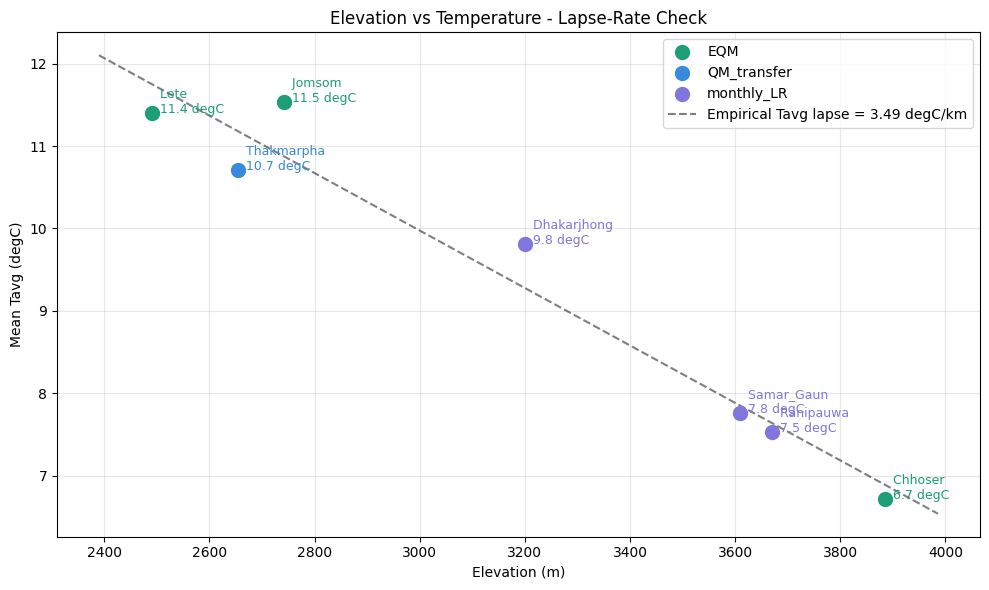

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'EQM':'#1D9E75','QM_transfer':'#378ADD','monthly_LR':'#7F77DD'}
methods = {'Jomsom':'EQM','Thakmarpha':'QM_transfer','Lete':'EQM',
           'Ranipauwa':'monthly_LR','Samar_Gaun':'monthly_LR',
           'Dhakarjhong':'monthly_LR','Chhoser':'EQM'}
labels_done = set()
tavg_by_elev = []
for s, meta in STATIONS.items():
    tdf=pd.read_csv(os.path.join(OUTPUT_DIR,f'{s}_temp_corrected.csv'))
    tavg=tdf['Tavg'].mean(); m=methods[s]; c=colors[m]
    tavg_by_elev.append((meta['elev'], tavg))
    label=m if m not in labels_done else None; labels_done.add(m)
    ax.scatter(meta['elev'],tavg,c=c,s=100,zorder=5,label=label)
    ax.annotate(f'  {s}\n  {tavg:.1f} degC',(meta['elev'],tavg),fontsize=9,color=c)

# fit the empirical Tavg lapse line from the corrected data itself
ev=np.array([e for e,_ in tavg_by_elev]); tv_=np.array([t for _,t in tavg_by_elev])
slope, intercept = np.polyfit(ev, tv_, 1)
emp_lr = -slope*1000
elevs=np.array([ev.min()-100, ev.max()+100])
ax.plot(elevs, intercept+slope*elevs, 'k--', alpha=0.5, lw=1.5,
        label=f'Empirical Tavg lapse = {emp_lr:.2f} degC/km')
ax.set_xlabel('Elevation (m)'); ax.set_ylabel('Mean Tavg (degC)'); ax.legend()
ax.set_title('Elevation vs Temperature - Lapse-Rate Check'); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,'elevation_vs_temp.png'),dpi=300); plt.show()